In [1]:
import jax.numpy as jnp
import numpy as np
import jax
import matplotlib.pyplot as plt

In [2]:
def transition_at_freq(freq, auto_regressive_coef, sampling_freq=1):
    if jnp.logical_or(auto_regressive_coef > 1, auto_regressive_coef < 0):
        raise ValueError("Auto-regressive coefficient must be between 0 and 1")

    freq = 2 * jnp.pi * freq / sampling_freq

    return auto_regressive_coef * jnp.array(
        [[jnp.cos(freq), -jnp.sin(freq)], [jnp.sin(freq), jnp.cos(freq)]]
    )


def process_covariance_at_freq(sigma):
    return sigma * jnp.eye(2)


def symmetrize(A):
    """Symmetrize one or more matrices."""
    return 0.5 * (A + jnp.swapaxes(A, -1, -2))


def psd_solve(A, b, diagonal_boost=1e-9):
    """A wrapper for coordinating the linalg solvers used in the library for psd matrices."""
    A = symmetrize(A) + diagonal_boost * jnp.eye(A.shape[-1])
    L, lower = jax.scipy.linalg.cho_factor(A, lower=True)
    return jax.scipy.linalg.cho_solve((L, lower), b)


def get_kalman_gain(P, H, R):
    # Optimization using Woodbury identity with A=R, U=H@chol(P), V=U.T, C=I
    # (see https://en.wikipedia.org/wiki/Woodbury_matrix_identity)
    I = jnp.eye(P.shape[0])
    U = H @ jnp.linalg.cholesky(P)
    X = U / R[:, None]
    S_inv = jnp.diag(1.0 / R) - X @ psd_solve(I + U.T @ X, X.T)
    K = P @ H.T @ S_inv
    S = jnp.diag(R) + H @ P @ H.T

    return K, S


def _kalman_filter_update(
    mean_prev: jnp.ndarray,
    cov_prev: jnp.ndarray,
    obs: jnp.ndarray,
    transition_matrix: jnp.ndarray,
    process_cov: jnp.ndarray,
    measurement_matrix: jnp.ndarray,
    measurement_cov: jnp.ndarray,
):
    """

    Parameters
    ----------
    mean_prev : jnp.ndarray, shape (n_cont_states,)
        Previous state mean.
    cov_prev : jnp.ndarray, shape (n_cont_states, n_cont_states)
        Previous state covariance.
    obs : jnp.ndarray, shape (n_obs_dim,)
        Data observation. $y_t$
    transition_matrix : jnp.ndarray, shape (n_cont_states, n_cont_states)
        State transition matrix. $A$
    process_cov : jnp.ndarray, shape (n_cont_states, n_cont_states)
        State noise covariance. $\Sigma$
    measurement_matrix : jnp.ndarray, shape (n_obs_dim, n_cont_states)
        Maps the observation to the state space. $H$
    measurement_cov : jnp.ndarray, shape (n_obs_dim, n_obs_dim)
        Observation noise covariance. $R$

    Returns
    -------
    posterior_mean : jnp.ndarray, shape (n_cont_states,)
        Posterior state mean.
    posterior_cov : jnp.ndarray, shape (n_cont_states, n_cont_states)
        Posterior state covariance.
    kalman_gain : jnp.ndarray, shape (n_cont_states, n_obs_dim)
        Kalman gain.
    marginal_log_likelihood : float
        Probability of the observation given the state.
    """

    # One step prediction
    one_step_mean = transition_matrix @ mean_prev
    one_step_cov = transition_matrix @ cov_prev @ transition_matrix.T + process_cov

    # Measurement update
    obs_mean = measurement_matrix @ one_step_mean
    # obs_cross_cov = one_step_cov @ measurement_matrix.T
    # project system uncertainty into measurement space
    obs_cov = measurement_matrix @ one_step_cov @ measurement_matrix.T + measurement_cov

    residual_error = obs - obs_mean  # innovation
    kalman_gain = jax.scipy.linalg.solve(
        obs_cov, measurement_matrix @ one_step_cov, assume_a="pos"
    ).T

    posterior_mean = one_step_mean + kalman_gain @ residual_error
    # More stable solution is P = (I-KH)P(I-KH)' + KRK'
    I_KH = jnp.eye(len(mean_prev)) - kalman_gain @ measurement_matrix
    posterior_cov = I_KH @ one_step_cov @ I_KH.T + kalman_gain @ (
        measurement_cov @ kalman_gain.T
    )

    # posterior_cov = one_step_cov - kalman_gain @ obs_cov @ kalman_gain.T

    marginal_log_likelihood = jax.scipy.stats.multivariate_normal.logpdf(
        x=residual_error, mean=jnp.zeros_like(residual_error), cov=obs_cov
    )
    # cross_variance = (jnp.identity(mean_prev.shape[0]) - kalman_gain @ measurement_matrix) @ transition_matrix @ cov_prev

    return posterior_mean, posterior_cov, kalman_gain, marginal_log_likelihood


_kalman_filter_update_per_discrete_state_pair = jax.vmap(
    jax.vmap(_kalman_filter_update, in_axes=(None, None, None, 2, 2, 2, 2)),
    in_axes=(1, 2, None, None, None, None, None),
)


@jax.jit
def collapse_MoG(
    conditional_means_x: jnp.ndarray,
    conditional_cov: jnp.ndarray,
    mixing_weights: jnp.ndarray,
) -> tuple[jnp.ndarray, jnp.ndarray]:
    """Collapse a mixture of Gaussians.

    Parameters
    ----------
    conditional_means_x : jnp.ndarray, shape (n_dims, n_discrete_states)
        E[X | S = j]
    conditional_cov : jnp.ndarray, shape (n_dims, n_dims, n_discrete_states)
        Cov[X | S = j]
    mixing_weights : jnp.ndarray, shape (n_discrete_states,)
        P[S = j]

    Returns
    -------
    unconditional_mean_x : jnp.ndarray, shape (n_dims,)
        E[X]
    unconditional_cov_x : jnp.ndarray, shape (n_dims, n_dims)
        Cov[X]
    """
    unconditional_mean_x = conditional_means_x @ mixing_weights  # E[X]
    diff_x = conditional_means_x - unconditional_mean_x[:, None]

    unconditional_cov_xx = (
        conditional_cov @ mixing_weights + (diff_x * mixing_weights) @ diff_x.T
    )  # E[XX]

    return unconditional_mean_x, unconditional_cov_xx


def collapse_MoG_cross(
    conditional_means_x: jnp.ndarray,
    conditional_means_y: jnp.ndarray,
    conditional_cross_cov: jnp.ndarray,
    mixing_weights: jnp.ndarray,
) -> tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """Collapse a mixture of Gaussians.

    Parameters
    ----------
    conditional_means_x : jnp.ndarray, shape (n_dims, n_discrete_states)
        E[X | S = j]
    conditional_means_y : jnp.ndarray, shape (n_dims, n_discrete_states)
        E[Y | S = j]
    conditional_cross_cov : jnp.ndarray, shape (n_dims, n_dims, n_discrete_states)
        E[X,Y | S = j]
    mixing_weights : jnp.ndarray, shape (n_discrete_states,)
        P[S = j]

    Returns
    -------
    unconditional_mean_x : jnp.ndarray, shape (n_dims,)
        E[X]
    unconditional_mean_y : jnp.ndarray, shape (n_dims,)
        E[Y]
    unconditional_cov_xy : jnp.ndarray, shape (n_dims, n_dims)
        E[X,Y]
    """

    unconditional_mean_x = conditional_means_x @ mixing_weights  # E[X]
    unconditional_mean_y = conditional_means_y @ mixing_weights  # E[Y]

    diff_x = conditional_means_x - unconditional_mean_x[:, None]
    diff_y = conditional_means_y - unconditional_mean_y[:, None]

    unconditional_cov_xy = (
        conditional_cross_cov @ mixing_weights + (diff_x * mixing_weights) @ diff_y.T
    )  # E[XY]

    return unconditional_mean_x, unconditional_mean_y, unconditional_cov_xy


collapse_MoG_across_states = jax.vmap(collapse_MoG, in_axes=(2, 3, 1), out_axes=(1, 2))


def _scale_likelihood(log_likelihood):
    ll_max = log_likelihood.max()
    ll_max = jnp.where(jnp.isfinite(ll_max), ll_max, 0.0)
    return jnp.exp(log_likelihood - ll_max), ll_max


def switching_kalman_filter(
    init_mean: jnp.ndarray,
    init_cov: jnp.ndarray,
    init_discrete_state_prob: jnp.ndarray,
    obs: jnp.ndarray,
    discrete_transition_matrix: jnp.ndarray,
    continuous_transition_matrix: jnp.ndarray,
    process_cov: jnp.ndarray,
    measurement_matrix: jnp.ndarray,
    measurement_cov: jnp.ndarray,
):
    """Switching Kalman filter for a linear Gaussian state space model with discrete states.

    Parameters
    ----------
    init_mean : jnp.ndarray, shape (n_cont_states,)
        Initial value of the continuous latent state $x_1$
    init_cov : jnp.ndarray, shape (n_cont_states, n_cont_states)
        Initial covariance of the continuous latent state $P_1$
    init_discrete_state_prob : jnp.ndarray, shape (n_discrete_states,)
        Initial probability of the discrete states $p(S_1)$
    obs : jnp.ndarray, shape (n_time, n_obs_dim)
        Observations $y_{1:T}$
    discrete_transition_matrix : jnp.ndarray, shape (n_discrete_states, n_discrete_states)
        Transition matrix for the discrete states $B$
    continuous_transition_matrix : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
        Transition matrix for the continuous states $A$
    process_cov : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
        Process noise covariance matrix. $\Sigma$
    measurement_matrix : jnp.ndarray, shape (n_obs_dims, n_cont_states, n_discrete_states)
        Map observations to the continuous states $H$
    measurement_cov : jnp.ndarray, shape (n_obs_dims, n_obs_dims, n_discrete_states)
        Measurement variance. $R$

    Returns
    -------
    filter_mean : jnp.ndarray, shape (n_time, n_cont_states)
        Filtered mean of the continuous latent state
    filter_cov : jnp.ndarray, shape (n_time, n_cont_states, n_cont_states)
        Filtered covariance of the continuous latent state
    filter_discrete_state_prob : jnp.ndarray, shape (n_time, n_discrete_states)
        Filtered probability of the discrete states

    """

    def _step(
        carry: tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray], obs_t: jnp.ndarray
    ) -> tuple[
        tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray],
        tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray],
    ]:
        """One step of the switching Kalman filter.

        Parameters
        ----------
        carry : tuple
            mean_prev : jnp.ndarray, shape (n_cont_states,)
                Previous state mean.
            cov_prev : jnp.ndarray, shape (n_cont_states, n_cont_states)
                Previous state covariance.
            discrete_state_prob_prev : jnp.ndarray, shape (n_discrete_states,)
                Previous discrete state probabilities
        obs_t : jnp.ndarray, shape (n_obs_dim,)
            Observation at time t

        Returns
        -------
        carry : tuple
            mean : jnp.ndarray, shape (n_cont_states,)
                Posterior state mean.
            cov : jnp.ndarray, shape (n_cont_states, n_cont_states)
                Posterior state covariance.
            discrete_state_prob : jnp.ndarray, shape (n_discrete_states,)
                Posterior discrete state probabilities
        stack : tuple
            mean : jnp.ndarray, shape (n_cont_states,)
                Posterior state mean.
            cov : jnp.ndarray, shape (n_cont_states, n_cont_states)
                Posterior state covariance.
            discrete_state_prob : jnp.ndarray, shape (n_discrete_states,)
                Posterior discrete state probabilities
            kalman_gain : jnp.ndarray, shape (n_cont_states, n_obs_dim)
                Kalman gain
        """
        mean_prev, cov_prev, discrete_state_prob_prev = carry

        # Kalman update for each pair of discrete states
        # P(x_t | y_{1:t}, S_t = j, S_{t-1} = i)
        # vmap twice over the discrete states
        (
            conditional_cont_means,
            conditional_cont_covs,
            kalman_gain,
            marginal_log_likelihood,
        ) = _kalman_filter_update_per_discrete_state_pair(
            mean_prev,
            cov_prev,
            obs_t,
            continuous_transition_matrix,
            process_cov,
            measurement_matrix,
            measurement_cov,
        )

        # Need to make sure the likelihood is normalized to max 1 for numerical stability
        conditional_marginal_likelihood, _ = _scale_likelihood(marginal_log_likelihood)

        # joint discrete state prob between time steps p(S_t, S_{t-1})
        joint_discrete_state_prob = (
            conditional_marginal_likelihood
            * discrete_transition_matrix
            * discrete_state_prob_prev[:, None]
        )
        joint_discrete_state_prob /= jnp.sum(joint_discrete_state_prob)

        # p(S_t)
        discrete_state_prob = jnp.sum(joint_discrete_state_prob, axis=0)
        # p(S_t | S_{t-1}) = p(S_t, S_{t-1}) / p(S_{t-1})
        discrete_state_weights = (
            joint_discrete_state_prob / discrete_state_prob[None, :]
        )

        # Collapse `n_discrete_states` x `n_discrete_states` Gaussians
        # to `n_discrete_states` Gaussians
        collapsed_means, collapsed_covs = collapse_MoG_across_states(
            conditional_cont_means,
            conditional_cont_covs,
            discrete_state_weights,
        )

        return (collapsed_means, collapsed_covs, discrete_state_prob), (
            collapsed_means,
            collapsed_covs,
            discrete_state_prob,
            kalman_gain,
        )

    (_, _, _), (filter_mean, filter_cov, filter_discrete_state_prob, kalman_gain) = (
        jax.lax.scan(
            _step,
            (init_mean, init_cov, init_discrete_state_prob),
            obs,
        )
    )

    return filter_mean, filter_cov, filter_discrete_state_prob, kalman_gain


def _kalman_smoother_update(
    next_smoother_mean,
    next_smoother_cov,
    filter_mean,
    filter_cov,
    process_cov,
    transition_matrix,
):
    one_step_mean = transition_matrix @ filter_mean
    one_step_cov = transition_matrix @ filter_cov @ transition_matrix.T + process_cov

    smoother_kalman_gain = jax.scipy.linalg.solve(
        one_step_cov, transition_matrix @ filter_cov, assume_a="pos"
    ).T

    smoother_mean = filter_mean + smoother_kalman_gain @ (
        next_smoother_mean - one_step_mean
    )
    smoother_cov = (
        filter_cov
        + smoother_kalman_gain
        @ (next_smoother_cov - one_step_cov)
        @ smoother_kalman_gain.T
    )

    smoother_cross_cov = filter_cov @ transition_matrix.T + smoother_kalman_gain @ (
        next_smoother_cov - one_step_cov
    )

    return smoother_mean, smoother_cov


_kalman_smoother_update_per_discrete_state_pair = jax.vmap(
    jax.vmap(_kalman_smoother_update, in_axes=(None, None, None, 2, 2, 2, 2)),
    in_axes=(1, 2, None, None, None, None, None),
)


def switching_kalman_smoother(
    filter_mean,
    filter_cov,
    filter_discrete_state_prob,
    kalman_gain,
    process_cov,
    continuous_transition_matrix,
    discrete_state_transition_matrix,
):

    def _step(carry, args):
        next_smoother_mean, next_smoother_cov, next_discrete_state_prob = carry
        filter_mean, filter_cov, filter_discrete_state_prob, kalman_gain = args

        # kalman smoother for all pairs of discrete states
        conditional_cont_means, conditional_cont_covs = (
            _kalman_smoother_update_per_discrete_state_pair(
                next_smoother_mean,
                next_smoother_cov,
                filter_mean,
                filter_cov,
                process_cov,
                continuous_transition_matrix,
            )
        )

        # Discrete smoother prob
        # P(S_t = j, S_{t+1} = k | y_{1:T})
        smoother_joint_discrete_state_prob = (
            filter_discrete_state_prob[:, None] * discrete_state_transition_matrix
        )
        smoother_joint_discrete_state_prob /= (
            jnp.sum(smoother_joint_discrete_state_prob, axis=1)
            * next_discrete_state_prob
        )
        # P(S_t = j | y_{1:T})
        smoother_discrete_state_prob = jnp.sum(
            smoother_joint_discrete_state_prob, axis=1
        )
        # P(S_{t+1} = k | y_{1:T})
        discrete_state_weights = (
            smoother_joint_discrete_state_prob / smoother_discrete_state_prob[:, None]
        )

        # Collapse `n_discrete_states` x `n_discrete_states` Gaussians
        # to `n_discrete_states` Gaussians
        collapsed_means, collapsed_covs = collapse_MoG_across_states(
            conditional_cont_means,
            conditional_cont_covs,
            discrete_state_weights,
        )
        # Collapse to a single Gaussian
        single_collapsed_means, single_collapsed_covs = collapse_MoG(
            collapsed_means, collapsed_covs, smoother_discrete_state_prob
        )

        # Cross covariance Cov(x_t, x_{t+1} | y_{1:T})

        return (collapsed_means, collapsed_covs, smoother_discrete_state_prob), (
            collapsed_means,
            collapsed_covs,
            smoother_discrete_state_prob,
        )

    (_, _, _), (smoother_means, smoother_covs, smoother_discrete_state_prob) = (
        jax.lax.scan(
            _step,
            (filter_mean[-1], filter_cov[-1], filter_discrete_state_prob[-1]),
            (filter_mean, filter_cov, filter_discrete_state_prob, kalman_gain),
            reverse=True,
        )
    )

    smoother_means = jnp.concatenate([smoother_means, smoother_means[-1][None]], axis=0)
    smoother_covs = jnp.concatenate([smoother_covs, smoother_covs[-1][None]], axis=0)
    smoother_discrete_state_prob = jnp.concatenate(
        [smoother_discrete_state_prob, smoother_discrete_state_prob[-1][None]], axis=0
    )

    return smoother_means, smoother_covs, smoother_discrete_state_prob


def _continuous_transition_update(
    discrete_state_prob: jnp.ndarray, P: jnp.ndarray, P_prev: jnp.ndarray
) -> jnp.ndarray:
    """Update the continuous transition matrix.

    corresponds to `A` matrix

    Parameters
    ----------
    discrete_state_prob : jnp.ndarray, shape (n_time, n_discrete_states)
        Probability of the discrete states.
    P : jnp.ndarray, shape (n_time, n_cont_states, n_cont_states)
        E[x_t, x_t | y_{1:T}]
    P_prev : jnp.ndarray, shape (n_time - 1, n_cont_states, n_cont_states)
        E[x_t, x_{t-1} | y_{1:T}]

    Returns
    -------
    continuous_transition_matrix : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
        Updated continuous transition matrix for each discrete state.
    """
    # shape (n_cont_states, n_cont_states, n_discrete_states)
    numerator = jnp.sum(
        discrete_state_prob[1:, None, None, :] * P_prev[:, :, :, None], axis=0
    )

    # shape (n_cont_states, n_cont_states, n_discrete_states)
    denom = jnp.sum(discrete_state_prob[1:, None, None, :] * P[1:, :, :, None], axis=0)

    n_discrete_states = discrete_state_prob.shape[-1]
    n_cont_states = P.shape[-1]

    continuous_transition_matrix = jnp.zeros(
        (n_cont_states, n_cont_states, n_discrete_states)
    )

    for j in range(n_discrete_states):
        continuous_transition_matrix = continuous_transition_matrix.at[:, :, j].set(
            jnp.linalg.solve(denom[:, :, j], numerator[:, :, j])
        )

    return continuous_transition_matrix


def _process_covariance_update(
    discrete_state_prob: jnp.ndarray,
    P: jnp.ndarray,
    P_prev: jnp.ndarray,
    continuous_transition_matrix: jnp.ndarray,
) -> jnp.ndarray:
    """Update the process covariance matrix for each discrete state.

    corresponds to `\sigma` matrix

    Parameters
    ----------
    discrete_state_prob : jnp.ndarray, shape (n_time, n_discrete_states)
        Probability of the discrete states.
    P : jnp.ndarray, shape (n_time, n_cont_states, n_cont_states)
        E[x_t, x_t | y_{1:T}]
    P_prev : jnp.ndarray, shape (n_time - 1, n_cont_states, n_cont_states)
        E[x_t, x_{t-1} | y_{1:T}]
    continuous_transition_matrix : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
        Updated continuous transition matrix for each discrete state

    Returns
    -------
    process_cov : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
        Updated process covariance matrix for each discrete state.

    """
    # shape (n_cont_states, n_cont_states, n_discrete_states)
    numerator = jnp.sum(
        discrete_state_prob[1:, None, None, :] * P[1:, :, :, None], axis=0
    )
    numerator -= continuous_transition_matrix @ jnp.sum(
        discrete_state_prob[1:, None, None, :] * P_prev[:, :, :, None], axis=0
    )

    # shape (n_discrete_states,)
    denom = jnp.sum(discrete_state_prob[1:], axis=0)

    return numerator / denom[None, None, :]


def _measurement_matrix_update(
    discrete_state_prob: jnp.ndarray,
    P: jnp.ndarray,
    obs: jnp.ndarray,
    collapsed_means: jnp.ndarray,
) -> jnp.ndarray:
    """Update the measurement matrix for each discrete state.

    Parameters
    ----------
    discrete_state_prob : jnp.ndarray, shape (n_time, n_discrete_states)
        Probability of the discrete states.
    P : jnp.ndarray, shape (n_time, n_cont_states, n_cont_states)
        E[x_t, x_t | y_{1:T}]
    obs : jnp.ndarray, shape (n_time, n_obs_dim)
        Observations
    collapsed_means : jnp.ndarray, shape (n_time, n_cont_states)
        E[X | S = j]

    Returns
    -------
    measurement_matrix : jnp.ndarray, shape (n_obs_dim, n_cont_states, n_discrete_states)
        Updated measurement matrix for each discrete state.
    """
    # shape (n_obs_dim, n_cont_states, n_discrete_states), use scan?
    numerator = jnp.sum(
        discrete_state_prob[:, None, None, :] * obs[:, :, None, None] * collapsed_means[:, None, :, None],
        axis=0,
    )
    # shape (n_obs_dim, n_discrete_states)
    denom =

    return numerator / denom[None, :]


def _measurement_covariance_update():
    pass


def _discrete_transition_update():
    pass


def EM_update(
    single_collapsed_means,
    single_collapsed_covs,
    smoother_cross_cov,
    discrete_state_prob,
):
    """

    Parameters
    ----------
    single_collapsed_means : jnp.ndarray, shape (n_time, n_latent_dims)
    single_collapsed_covs : jnp.ndarray, shape (n_time, n_latent_dims, n_latent_dims)
    smoother_cross_cov : jnp.ndarray, shape (n_time - 1, n_latent_dims, n_latent_dims)
    discrete_state_prob : jnp.ndarray, shape (n_time, n_discrete_states)
    """
    # want outer product of each of these with itself
    xxT = (
        single_collapsed_means[:, :, None] @ single_collapsed_means[:, None, :]
    )  # shape (n_time, n_latent_dims, n_latent_dims)
    # E[x_t, x_{t}.T | y_{1:T}]
    P = xxT + single_collapsed_covs  # shape (n_time, n_latent_dims, n_latent_dims)
    # E[x_t, x_{t-1}.T | y_{1:T}]
    xx_1T = (
        single_collapsed_means[1:, :, None] @ single_collapsed_means[:-1, None, :]
    )  # shape (n_time - 1, n_latent_dims, n_latent_dims)
    P_prev = (
        xx_1T + smoother_cross_cov
    )  # shape (n_time - 1, n_latent_dims, n_latent_dims)



# init_mean : jnp.ndarray, shape (n_cont_states,)
#     Initial value of the continuous latent state $x_1$
# init_cov : jnp.ndarray, shape (n_cont_states, n_cont_states)
#     Initial covariance of the continuous latent state $P_1$
# init_discrete_state_prob : jnp.ndarray, shape (n_discrete_states,)
#     Initial probability of the discrete states $p(S_1)$
# obs : jnp.ndarray, shape (n_time, n_obs_dim)
#     Observations $y_{1:T}$
# discrete_transition_matrix : jnp.ndarray, shape (n_discrete_states, n_discrete_states)
#     Transition matrix for the discrete states $B$
# continuous_transition_matrix : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
#     Transition matrix for the continuous states $A$
# process_cov : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
#     Process noise covariance matrix. $\Sigma$
# measurement_matrix : jnp.ndarray, shape (n_obs_dims, n_cont_states, n_discrete_states)
#     Map observations to the continuous states $H$ or $B$
# measurement_cov : jnp.ndarray, shape (n_obs_dims, n_obs_dims, n_discrete_states)
#     Measurement variance. $R$

def EM_update2(
    single_collapsed_means,
    single_collapsed_covs,
    smoother_cross_cov,
    discrete_state_prob,
    obs,
    ):
    def _step(carry, t):
        expected_x  = single_collapsed_means[t] # shape (n_cont_states,)
        expected_x_prev = single_collapsed_means[t-1] # shape (n_cont_states,)
        expected_cov_x = jnp.outer(expected_x, expected_x) + single_collapsed_covs[t] # P_{t}, shape (n_cont_states, n_cont_states)
        expected_cross_cov_x = jnp.outer(expected_x, expected_x_prev) + smoother_cross_cov[t] # P_{t, t-1}, shape (n_cont_states, n_cont_states)

        discrete_prob_t = discrete_state_prob[t] # shape (n_discrete_states,)
        obs_t = obs[t] # shape (n_obs_dim,)

        weighted_expected_cross_cov_x = discrete_prob_t[None, None, :] * expected_cross_cov_x[:, :, None] # shape (n_cont_states, n_cont_states, n_discrete_states)
        weighted_expected_cov_x = discrete_prob_t[None, None, :] * expected_cov_x[:, :, None] # shape (n_cont_states, n_cont_states, n_discrete_states)

        gyx = discrete_state_prob_t[None, None, :] * obs_t[:, None, None] * expected_x[None, :, None] # shape (n_obs_dim, n_cont_states, n_discrete_states)


SyntaxError: invalid syntax (3647529394.py, line 587)

In [ ]:
# B1 shape (n_obs, n_cont_states, n_discrete_states, n_time)
# B2 shape (n_cont_states, n_cont_states, n_discrete_states, n_time)
# B1_sum shape (n_obs, n_cont_states, n_time) sum over discrete states
# B2_sum shape (n_cont_states, n_cont_states, n_time) sum over discrete states
# Bj = zeros(n_obs,dim_state,M,iter);

# B1(:,:,j,t) = M_j(t,j) * (y(t,:)' * X_RTS(:,t)');
# B2(:,:,j,t) = M_j(t,j) * (V_RTS(:,:,t) + X_RTS(:,t)*X_RTS(:,t)');

# Bj(:,:,j,itr+1) = B1sum(:,:,j)*inv(B2sum(:,:,j));   % analytic sol

In [ ]:
n_time = 10
n_cont_states = 2
single_collapsed_means = np.random.rand(n_time, n_cont_states)

np.outer?

In [ ]:
np.outer(single_collapsed_means[0], single_collapsed_means[0])

In [ ]:
def make_transition_matrix(freqs, auto_regressive_coefs, sampling_freq=1):
    return jax.scipy.linalg.block_diag(
        *[
            transition_at_freq(freq, auto_regressive_coef, sampling_freq)
            for freq, auto_regressive_coef in zip(freqs, auto_regressive_coefs)
        ]
    )


def make_process_covariance(sigmas):
    return jax.scipy.linalg.block_diag(
        *[process_covariance_at_freq(sigma) for sigma in sigmas]
    )


make_process_covariance([1, 2, 3])

In [ ]:
transition_at_freq(0.1, 0.9)

In [ ]:
import numpy as np


def compute_terms_np(discrete_state_prob, P, P_prev, y, x_hat):
    n_time, n_discrete_states = discrete_state_prob.shape
    n_cont_states = P.shape[1]
    n_obs_dim = y.shape[1]

    B1 = np.zeros((n_obs_dim, n_cont_states, n_discrete_states, n_time))
    B2 = np.zeros((n_cont_states, n_cont_states, n_discrete_states, n_time))

    for t in range(n_time):
        for j in range(n_discrete_states):
            B1[:, :, j, t] = discrete_state_prob[t, j] * np.outer(y[t, :], x_hat[t, :])
            B2[:, :, j, t] = discrete_state_prob[t, j] * (
                P[t, :, :] + np.outer(x_hat[t, :], x_hat[t, :])
            )

    B1_sum = np.sum(
        B1, axis=2
    )  # Sum over discrete states, shape: (n_obs_dim, n_cont_states, n_time)
    B2_sum = np.sum(
        B2, axis=2
    )  # Sum over discrete states, shape: (n_cont_states, n_cont_states, n_time)

    return B1_sum, B2_sum


def update_parameters_np(discrete_state_prob, P, P_prev, y, x_hat, itr):
    n_time, n_discrete_states = discrete_state_prob.shape
    n_cont_states = P.shape[1]
    n_obs_dim = y.shape[1]

    B1_sum, B2_sum = compute_terms_np(discrete_state_prob, P, P_prev, y, x_hat)

    # Initialize Bj
    Bj = np.zeros((n_obs_dim, n_cont_states, n_discrete_states, itr + 1))

    for j in range(n_discrete_states):
        for t in range(n_time):
            Bj[:, :, j, itr] = np.dot(B1_sum[:, :, t], np.linalg.inv(B2_sum[:, :, t]))

    return Bj


# Example usage with dummy data
n_time = 5
n_discrete_states = 3
n_cont_states = 2
n_obs_dim = 2
itr = 10

# Dummy data for the inputs
np.random.seed(42)
discrete_state_prob = np.random.rand(
    n_time, n_discrete_states
)  # Shape: (n_time, n_discrete_states)
P = np.random.rand(
    n_time, n_cont_states, n_cont_states
)  # Shape: (n_time, n_cont_states, n_cont_states)
P_prev = np.random.rand(
    n_time - 1, n_cont_states, n_cont_states
)  # Shape: (n_time - 1, n_cont_states, n_cont_states)
y = np.random.rand(n_time, n_obs_dim)  # Shape: (n_time, n_obs_dim)
x_hat = np.random.rand(n_time, n_cont_states)  # Shape: (n_time, n_cont_states)

# Perform the parameter update
Bj = update_parameters_np(discrete_state_prob, P, P_prev, y, x_hat, itr)
print("Bj:", Bj)

In [ ]:
n_time, n_discrete_states = discrete_state_prob.shape
n_cont_states = P.shape[1]
n_obs_dim = y.shape[1]

B1_sum, B2_sum = compute_terms_np(discrete_state_prob, P, P_prev, y, x_hat)

In [ ]:
B1_sum.shape

In [ ]:
B2_sum.shape

In [ ]:
np.dot(B1_sum[:, :, t], np.linalg.inv(B2_sum[:, :, t]))

In [ ]:
Bj.shape

In [ ]:
# init_mean : jnp.ndarray, shape (n_cont_states,)
#     Initial value of the continuous latent state $x_1$
# init_cov : jnp.ndarray, shape (n_cont_states, n_cont_states)
#     Initial covariance of the continuous latent state $P_1$
# init_discrete_state_prob : jnp.ndarray, shape (n_discrete_states,)
#     Initial probability of the discrete states $p(S_1)$
# obs : jnp.ndarray, shape (n_time, n_obs_dim)
#     Observations $y_{1:T}$
# discrete_transition_matrix : jnp.ndarray, shape (n_discrete_states, n_discrete_states)
#     Transition matrix for the discrete states $B$
# continuous_transition_matrix : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
#     Transition matrix for the continuous states $A$
# process_cov : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
#     Process noise covariance matrix. $\Sigma$
# measurement_matrix : jnp.ndarray, shape (n_obs_dims, n_cont_states, n_discrete_states)
#     Map observations to the continuous states $H$ or $B$
# measurement_cov : jnp.ndarray, shape (n_obs_dims, n_obs_dims, n_discrete_states)
#     Measurement variance. $R$


def update_continuous_transition_matrix(
    discrete_state_prob: np.ndarray, x: np.ndarray, V: np.ndarray, cross_V: np.ndarray
) -> np.ndarray:
    """Update the continuous transition matrix.

    Parameters
    ----------
    discrete_state_prob : np.ndarray, shape (n_time, n_discrete_states)
    x : np.ndarray, shape (n_time, n_cont_states)
        Continuous latent states (collapsed means)
    V : np.ndarray, shape (n_time, n_cont_states, n_cont_states)
        Covariance of the continuous latent states (collapsed covariances)
    V_cross : np.ndarray, shape (n_time - 1, n_cont_states, n_cont_states)

    Returns
    -------
    continuous_transition_matrix : np.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
    """
    n_time, n_cont_states = x.shape
    n_discrete_states = discrete_state_prob.shape[1]

    a1 = np.zeros((n_cont_states, n_cont_states, n_discrete_states))
    a2 = np.zeros((n_cont_states, n_cont_states, n_discrete_states))
    continuous_transition_matrix = np.zeros(
        (n_cont_states, n_cont_states, n_discrete_states)
    )

    for i in range(n_discrete_states):
        for t in range(1, n_time):
            # shape (n_cont_states, n_cont_states)
            P_t_t_minus1 = np.outer(x[t], x[t - 1]) + cross_V[t - 1]
            a1[:, :, i] += discrete_state_prob[t, i] * P_t_t_minus1

            P_t_minus1 = np.outer(x[t - 1], x[t - 1]) + V[t]
            a2[:, :, i] += discrete_state_prob[t, i] * P_t_minus1

    for i in range(n_discrete_states):
        # A[:, :, i] = np.linalg.solve(a2[:, :, i], a1[:, :, i])
        continuous_transition_matrix[:, :, i] = a1[:, :, i] @ np.linalg.inv(a2[:, :, i])

    return continuous_transition_matrix


n_time = 10
n_discrete_states = 3
n_cont_states = 2
n_obs_dim = 4

discrete_state_prob = np.random.rand(n_time, n_discrete_states)
x = np.random.rand(n_time, n_cont_states)
V = np.random.rand(n_time, n_cont_states, n_cont_states)
cross_V = np.random.rand(n_time - 1, n_cont_states, n_cont_states)
y = np.random.rand(n_time, n_obs_dim)

updated_continuous_transition_matrix = update_continuous_transition_matrix(
    discrete_state_prob, x, V, cross_V
)

In [ ]:
def update_process_cov(
    discrete_state_prob: np.ndarray,
    x: np.ndarray,
    V: np.ndarray,
    cross_V: np.ndarray,
    updated_continuous_transition_matrix: np.ndarray,
) -> np.ndarray:
    """Update the process covariance matrix.

    Parameters
    ----------
    discrete_state_prob : np.ndarray, shape (n_time, n_discrete_states)
    x : np.ndarray, shape (n_time, n_cont_states)
    V : np.ndarray, shape (n_time, n_cont_states, n_cont_states)
    cross_V : np.ndarray, shape (n_time - 1, n_cont_states, n_cont_states)
    updated_continuous_transition_matrix : np.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)

    Returns
    -------
    process_cov : np.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
    """
    n_time, n_cont_states = x.shape
    n_discrete_states = discrete_state_prob.shape[1]

    process_cov = np.zeros((n_cont_states, n_cont_states, n_discrete_states))

    sigma1 = discrete_state_prob[1:].sum(axis=0)
    sigma2 = np.zeros((n_cont_states, n_cont_states, n_discrete_states))
    sigma3 = np.zeros((n_cont_states, n_cont_states, n_discrete_states))

    for i in range(n_discrete_states):
        for t in range(1, n_time):
            P_t = np.outer(x[t], x[t]) + V[t]
            sigma2[:, :, i] += discrete_state_prob[t, i] * P_t

            P_t_t_minus1 = np.outer(x[t], x[t - 1]) + cross_V[t - 1]
            sigma3[:, :, i] += discrete_state_prob[t, i] * P_t_t_minus1

    for i in range(n_discrete_states):
        # is this a matrix multiplication or element-wise?
        process_cov[:, :, i] = (
            sigma2[:, :, i]
            - updated_continuous_transition_matrix[:, :, i] @ sigma3[:, :, i]
        ) / sigma1[i]

    return process_cov


update_process_cov(
    discrete_state_prob, x, V, cross_V, updated_continuous_transition_matrix
)

In [ ]:
def update_measurement_matrix(
    discrete_state_prob: np.ndarray,
    x: np.ndarray,
    y: np.ndarray,
    V: np.ndarray,
) -> np.ndarray:
    """Update the measurement matrix.

    Parameters
    ----------
    discrete_state_prob : np.ndarray, shape (n_time, n_discrete_states)
    x : np.ndarray, shape (n_time, n_cont_states)
    y : np.ndarray, shape (n_time, n_obs_dim)
    V : np.ndarray, shape (n_time, n_cont_states, n_cont_states)

    Returns
    -------
    updated_measurement_matrix : np.ndarray, shape (n_obs_dim, n_cont_states, n_discrete_states)
    """
    n_obs_dim = y.shape[1]
    n_time, n_cont_states = x.shape
    n_discrete_states = discrete_state_prob.shape[1]

    b1 = np.zeros((n_obs_dim, n_cont_states, n_discrete_states))
    b2 = np.zeros((n_cont_states, n_cont_states, n_discrete_states))

    for i in range(n_discrete_states):
        for t in range(n_time):
            b1[:, :, i] += discrete_state_prob[t, i] * np.outer(y[t], x[t].T)

            P_t = np.outer(x[t], x[t]) + V[t]
            b2[:, :, i] += discrete_state_prob[t, i] * P_t

    measurement_matrix = np.zeros((n_obs_dim, n_cont_states, n_discrete_states))
    for i in range(n_discrete_states):
        measurement_matrix[:, :, i] = b1[:, :, i] @ np.linalg.inv(b2[:, :, i])

    return measurement_matrix


updated_measurement_matrix = update_measurement_matrix(discrete_state_prob, x, y, V)

In [ ]:
def update_measurement_matrix2(
    discrete_state_prob: np.ndarray,
    x: np.ndarray,
    y: np.ndarray,
    V: np.ndarray,
) -> np.ndarray:
    """Update the measurement matrix.

    Parameters
    ----------
    discrete_state_prob : np.ndarray, shape (n_time, n_discrete_states)
    x : np.ndarray, shape (n_time, n_cont_states)
    y : np.ndarray, shape (n_time, n_obs_dim)
    V : np.ndarray, shape (n_time, n_cont_states, n_cont_states)

    Returns
    -------
    updated_measurement_matrix : np.ndarray, shape (n_obs_dim, n_cont_states, n_discrete_states)
    """
    n_obs_dim = y.shape[1]
    n_time, n_cont_states = x.shape
    n_discrete_states = discrete_state_prob.shape[1]

    b2 = np.zeros((n_cont_states, n_cont_states, n_discrete_states))

    # shape (n_obs_dim, n_cont_states, n_discrete_states)
    b1 = np.einsum("tc, tod -> ocd", x, discrete_state_prob[:, None, :] * y[:, :, None])

    # b2 = (
    #     np.einsum("tc, tbd -> cbd", x, discrete_state_prob[:, None, :] * x[:, :, None])
    #     + V.sum(axis=0)[..., None]
    # )

    for i in range(n_discrete_states):
        for t in range(n_time):

            P_t = np.outer(x[t], x[t]) + V[t]
            b2[:, :, i] += discrete_state_prob[t, i] * P_t

    measurement_matrix = np.zeros((n_obs_dim, n_cont_states, n_discrete_states))
    # for i in range(n_discrete_states):
    #     measurement_matrix[:, :, i] = b1[:, :, i] @ np.linalg.inv(b2[:, :, i])
    for i in range(n_discrete_states):
        measurement_matrix[:, :, i] = np.linalg.solve(b2[:, :, i], b1[:, :, i].T).T

    return measurement_matrix


updated_measurement_matrix2 = update_measurement_matrix2(discrete_state_prob, x, y, V)

np.allclose(updated_measurement_matrix, updated_measurement_matrix2)

In [ ]:
(discrete_state_prob[:, None, :] * y[:, :, None]).shape

In [ ]:
x.shape

In [ ]:
V.shape

In [ ]:
(
    np.einsum("tc, tbd -> cbd", x, discrete_state_prob[:, None, :] * x[:, :, None])
    + V.sum(axis=0)[..., None]
)

In [ ]:
def update_measurement_cov(
    discrete_state_prob: np.ndarray,
    y: np.ndarray,
    x: np.ndarray,
    updated_measurement_matrix: np.ndarray,
) -> np.ndarray:
    """Update the measurement covariance matrix.

    Parameters
    ----------
    discrete_state_prob : np.ndarray, shape (n_time, n_discrete_states)
    y : np.ndarray, shape (n_time, n_obs_dim)
    x : np.ndarray, shape (n_time, n_cont_states)
    updated_measurement_matrix : np.ndarray, shape (n_obs_dim, n_cont_states, n_discrete_states)

    Returns
    -------
    updated_measurement_cov : np.ndarray, shape (n_obs_dim, n_obs_dim, n_discrete_states)

    """
    n_time, n_discrete_states = discrete_state_prob.shape
    n_obs_dim = y.shape[1]

    measurement_cov = np.zeros((n_obs_dim, n_obs_dim, n_discrete_states))

    r1 = discrete_state_prob.sum()
    r2 = np.zeros((n_obs_dim, n_obs_dim, n_discrete_states))
    r3 = np.zeros((n_obs_dim, n_obs_dim, n_discrete_states))

    for t in range(n_time):
        for i in range(n_discrete_states):
            r2[:, :, i] += discrete_state_prob[t, i] * np.outer(y[t], y[t])
            r3[:, :, i] += discrete_state_prob[t, i] * np.outer(
                y[t], updated_measurement_matrix[:, :, i] @ x[t]
            )

    for i in range(n_discrete_states):
        measurement_cov[:, :, i] = (r2[:, :, i] - r3[:, :, i]) / r1

    return measurement_cov


update_measurement_cov(discrete_state_prob, y, x, updated_measurement_matrix)

In [ ]:
def update_measurement_cov2(
    discrete_state_prob: np.ndarray,
    y: np.ndarray,
    x: np.ndarray,
    updated_measurement_matrix: np.ndarray,
) -> np.ndarray:
    """Update the measurement covariance matrix.

    Parameters
    ----------
    discrete_state_prob : np.ndarray, shape (n_time, n_discrete_states)
    y : np.ndarray, shape (n_time, n_obs_dim)
    x : np.ndarray, shape (n_time, n_cont_states)
    updated_measurement_matrix : np.ndarray, shape (n_obs_dim, n_cont_states, n_discrete_states)

    Returns
    -------
    updated_measurement_cov : np.ndarray, shape (n_obs_dim, n_obs_dim, n_discrete_states)

    """
    n_time, n_discrete_states = discrete_state_prob.shape
    n_obs_dim = y.shape[1]

    measurement_cov = np.zeros((n_obs_dim, n_obs_dim, n_discrete_states))

    r1 = discrete_state_prob.sum()
    r2 = np.zeros((n_obs_dim, n_obs_dim, n_discrete_states))
    r3 = np.zeros((n_obs_dim, n_obs_dim, n_discrete_states))

    for t in range(n_time):
        for i in range(n_discrete_states):
            r2[:, :, i] += discrete_state_prob[t, i] * np.outer(y[t], y[t])
            r3[:, :, i] += discrete_state_prob[t, i] * np.outer(
                y[t], updated_measurement_matrix[:, :, i] @ x[t]
            )

    for i in range(n_discrete_states):
        measurement_cov[:, :, i] = (r2[:, :, i] - r3[:, :, i]) / r1

    return measurement_cov


np.allclose(
    update_measurement_cov(discrete_state_prob, y, x, updated_measurement_matrix),
    update_measurement_cov2(discrete_state_prob, y, x, updated_measurement_matrix),
)

In [ ]:
# init_mean : jnp.ndarray, shape (n_cont_states,)
#     Initial value of the continuous latent state $x_1$
# init_cov : jnp.ndarray, shape (n_cont_states, n_cont_states)
#     Initial covariance of the continuous latent state $P_1$
# init_discrete_state_prob : jnp.ndarray, shape (n_discrete_states,)
#     Initial probability of the discrete states $p(S_1)$
# obs : jnp.ndarray, shape (n_time, n_obs_dim)
#     Observations $y_{1:T}$
# discrete_transition_matrix : jnp.ndarray, shape (n_discrete_states, n_discrete_states)
#     Transition matrix for the discrete states $B$
# continuous_transition_matrix : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
#     Transition matrix for the continuous states $A$
# process_cov : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
#     Process noise covariance matrix. $\Sigma$
# measurement_matrix : jnp.ndarray, shape (n_obs_dims, n_cont_states, n_discrete_states)
#     Map observations to the continuous states $H$ or $B$
# measurement_cov : jnp.ndarray, shape (n_obs_dims, n_obs_dims, n_discrete_states)
#     Measurement variance. $R$

from typing import Optional


def switching_kalman_maximization_step(
    obs: jnp.ndarray,
    smoothed_mean: jnp.ndarray,
    smoothed_cov: jnp.ndarray,
    smoothed_cross_cov: jnp.ndarray,
    discrete_state_prob: jnp.ndarray,
    outer_obs: Optional[jnp.ndarray] = None,
):
    """Maximization step for the Kalman filter.

    Parameters
    ----------
    obs : jnp.ndarray, shape (n_time, n_obs_dim)
        Observations.
    smoothed_mean : jnp.ndarray, shape (n_time, n_cont_states)
        Smoothed mean.
    smoothed_cov : jnp.ndarray, shape (n_time, n_cont_states, n_cont_states)
        Smoothed covariance.
    smoothed_cross_cov : jnp.ndarray, shape (n_time - 1, n_cont_states, n_cont_states)
        Smoothed cross-covariance.
    discrete_state_prob : jnp.ndarray, shape (n_time, n_discrete_states)
        Probability of the discrete states.
    outer_obs : jnp.ndarray, shape (n_obs_dim, n_obs_dim, n_discrete_states)
        Outer product of the observations. Default is None.

    Returns
    -------
    transition_matrix : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
        Transition matrix.
    measurement_matrix : jnp.ndarray, shape (n_obs_dim, n_cont_states, n_discrete_states)
        Measurement matrix.
    process_cov : jnp.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
        Process covariance.
    measurement_cov : jnp.ndarray, shape (n_obs_dim, n_obs_dim, n_discrete_states)
        Measurement covariance.
    mean_init : jnp.ndarray, shape (n_cont_states,)
        Initial mean.
    cov_init : jnp.ndarray, shape (n_cont_states, n_cont_states)
        Initial covariance.

    References
    ----------
    ... [1] Roweis, S. T., Ghahramani, Z., & Hinton, G. E. (1999). A unifying review of
    linear Gaussian models. Neural computation, 11(2), 305-345.
    """
    if outer_obs is None:
        outer_obs = jnp.einsum("ti,tj,tk->ijk", obs, obs, discrete_state_prob)

    n_cont_states = smoothed_mean.shape[1]

    # outer products
    # y_t x_t.T
    delta = jnp.einsum("ti,tj,tk->ijk", obs, smoothed_mean, discrete_state_prob)
    # P_t = E[x_t, x_t] = x_t x_t.T + V_t
    gamma = jnp.einsum(
        "ti,tj,tk->ijk", smoothed_mean, smoothed_mean, discrete_state_prob
    ) + jnp.einsum("tij,td->ijd", smoothed_cov, discrete_state_prob)
    # P_{t, t-1} = E[x_t, x_{t-1}]
    beta = jnp.einsum(
        "ti,tj,tk->ijk", smoothed_mean[1:], smoothed_mean[:-1], discrete_state_prob[1:]
    ) + jnp.einsum("tij,td->ijd", smoothed_cross_cov, discrete_state_prob[1:])

    gamma1 = (
        gamma
        - jnp.einsum(
            "i,j,k->ijk", smoothed_mean[-1], smoothed_mean[-1], discrete_state_prob[-1]
        )
        - jnp.einsum("ij,k->ijk", smoothed_cov[-1], discrete_state_prob[-1])
    )
    gamma2 = (
        gamma
        - jnp.einsum(
            "i,j,k->ijk", smoothed_mean[0], smoothed_mean[0], discrete_state_prob[0]
        )
        - jnp.einsum("ij,k->ijk", smoothed_cov[0], discrete_state_prob[0])
    )

    # Regularization to improve numerical stability (optional)
    epsilon = 1e-6
    gamma += epsilon * jnp.eye(n_cont_states)[..., None]
    gamma1 += epsilon * jnp.eye(n_cont_states)[..., None]

    measurement_matrix = jnp.stack(
        [
            jnp.linalg.solve(gamma[..., s], delta[..., s].T).T
            for s in range(n_discrete_states)
        ],
        axis=-1,
    )

    summed_prob = jnp.sum(discrete_state_prob, axis=0)
    measurement_cov = (
        jnp.stack(
            [
                (outer_obs[..., s] - delta[..., s] @ measurement_matrix[..., s].T)
                for s in range(n_discrete_states)
            ],
            axis=-1,
        )
        / summed_prob
    )
    transition_matrix = jnp.stack(
        [
            jnp.linalg.solve(gamma1[..., s], beta[..., s].T).T
            for s in range(n_discrete_states)
        ],
        axis=-1,
    )
    process_cov = jnp.stack(
        [
            (gamma2[..., s] - beta[..., s] @ transition_matrix[..., s].T)
            for s in range(n_discrete_states)
        ],
        axis=-1,
    ) / (summed_prob - discrete_state_prob[-1])

    mean_init = smoothed_mean[0]
    cov_init = smoothed_cov[0]

    return (
        transition_matrix,
        measurement_matrix,
        process_cov,
        measurement_cov,
        mean_init,
        cov_init,
    )


n_time = 10
n_cont_states = 2
n_obs_dim = 4
n_discrete_states = 3

discrete_state_prob = np.random.rand(n_time, n_discrete_states)
smoothed_mean = np.random.rand(n_time, n_cont_states)
smoothed_cov = np.random.rand(n_time, n_cont_states, n_cont_states)
smoothed_cross_cov = np.random.rand(n_time - 1, n_cont_states, n_cont_states)
obs = np.random.rand(n_time, n_obs_dim)

switching_kalman_maximization_step(
    obs, smoothed_mean, smoothed_cov, smoothed_cross_cov, discrete_state_prob
)

In [ ]:
jnp.allclose(
    jnp.sum(
        smoothed_cross_cov[..., None] * discrete_state_prob[1:, None, None, :], axis=0
    ),
    jnp.einsum("tij,td->ijd", smoothed_cross_cov, discrete_state_prob[1:]),
)

In [ ]:
smoothed_cross_cov.shape

In [ ]:
jnp.allclose(
    jnp.sum(discrete_state_prob[:, None, None, :] * smoothed_cov[..., None], axis=0),
    jnp.einsum("tij,td->ijd", smoothed_cov, discrete_state_prob),
)

In [ ]:
jnp.stack([jnp.linalg.solve(gamma[..., s], delta[..., s].T).T for s in range(n_discrete_states)], axis=-1)


(100.0, 105.0)

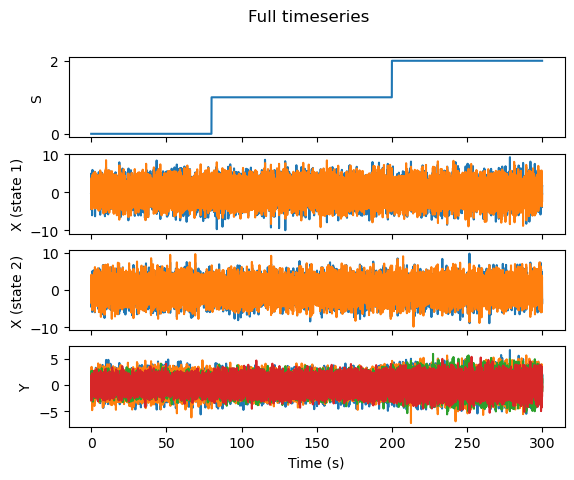

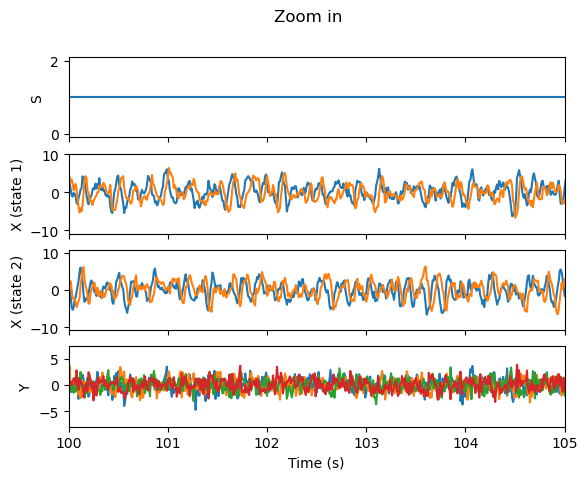

In [3]:
import matplotlib.pyplot as plt
from state_space_practice.simulate.simulate_switching_kalman import simulate_model
import jax.numpy as jnp

(
    fs,
    k,
    n,
    M,
    osc_freqs,
    rhos,
    var_state_nois,
    var_obs_noi,
    A,
    Q,
    R,
    B,
    Z,
    X0,
    S0,
    x_dim,
    s,
    y,
    x,
    ta,
) = simulate_model()
V0 = jnp.eye(x_dim) * 1e-2
V0 = jnp.tile(V0[:, :, None], (1, 1, M))

X0 = jnp.tile(X0[:, None], (1, M))


fig, axs = plt.subplots(2 + k, 1, sharex=True)
axs[0].plot(ta, s)
axs[0].set_ylabel("S")
for i in range(k):
    axs[1 + i].plot(ta, x[:, 2 * i : 2 * i + 2])
    axs[1 + i].set_ylabel(f"X (state {i+1})")
axs[k + 1].plot(ta, y)
axs[k + 1].set_ylabel("Y")
axs[k + 1].set_xlabel("Time (s)")
fig.suptitle("Full timeseries")

fig, axs = plt.subplots(2 + k, 1, sharex=True)
axs[0].plot(ta, s)
axs[0].set_ylabel("S")
for i in range(k):
    axs[1 + i].plot(ta, x[:, 2 * i : 2 * i + 2])
    axs[1 + i].set_ylabel(f"X (state {i+1})")
axs[k + 1].plot(ta, y)
axs[k + 1].set_ylabel("Y")
axs[k + 1].set_xlabel("Time (s)")
fig.suptitle("Zoom in")
axs[0].set_xlim([100, 105])

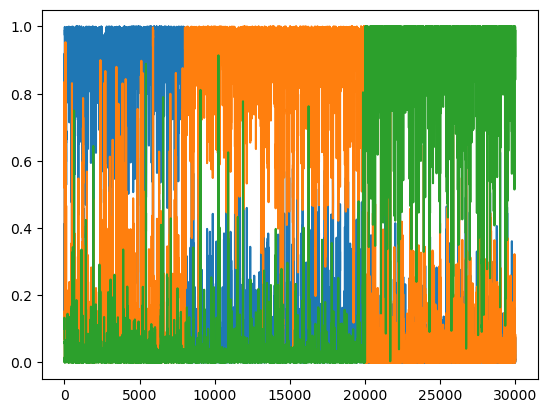

In [4]:
from state_space_practice.switching_kalman import (
    switching_kalman_filter,
)


filter_mean, filter_cov, filter_discrete_state_prob = switching_kalman_filter(
    init_mean=X0,
    init_cov=V0,
    init_discrete_state_prob=jnp.ones(M) / M,
    obs=y,
    discrete_transition_matrix=Z,
    continuous_transition_matrix=A,
    process_cov=Q,
    measurement_matrix=B,
    measurement_cov=R,
)

plt.plot(filter_discrete_state_prob)

In [5]:
from state_space_practice.switching_kalman import (
    switching_kalman_smoother,
)

switching_kalman_smoother(
    filter_mean,
    filter_cov,
    filter_discrete_state_prob,
    process_cov=Q,
    continuous_transition_matrix=A,
    discrete_state_transition_matrix=Z,
)

ValueError: not enough values to unpack (expected 4, got 3)

In [ ]:
jnp.tile(X0[:, None], (1, M)).shape

In [ ]:
from state_space_practice.switching_kalman import _kalman_filter_update

for i in range(M):
    for j in range(M):
        _kalman_filter_update(
            mean_prev=X0,
            cov_prev=V0,
            obs=y[0],
            transition_matrix=A,
            process_cov=Q,
            measurement_matrix=B,
            measurement_cov=R,
        )